# Part 2: Visualizing TEK 

In this part, we are loading in a new dataset with the TEK site rankings, and summarizing it to combine with our water quality data. The end result is a plot that includes both the water quality metrics and ranking of TEK site. The file `TEKresponses.csv` contains survey results that asked community members to rank the importance of each site's location for cultural use. 

We will use more `tidyverse` functions and ggplot for plotting. 
New functions include: `pivot_longer()`, `inner_join()` 

*Note: if you are starting from the beginning and have not recently done part 1: Kavi_Tribe_Water_Quality.R, you may want to load your packages and set your working directory*

In [3]:
# load tidyverse package 
library(tidyverse)
# make plots larger 
options(repr.plot.width = 12, repr.plot.height = 8)

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [15]:
#import survey data file
tek_values <- read.csv("TEKresponses.csv")

#delete unnecessary timestamp column
# in this example we are selecting every column except the one listed, we use a negative sign to say "Don't Select"
tek_values <- tek_values %>%
  select(-"Timestamp")

# preview what data frame looks like 
str(tek_values)

Warning message in read.table(file = file, header = header, sep = sep, quote = quote, :
"incomplete final line found by readTableHeader on 'TEKresponses.csv'"


'data.frame':	4 obs. of  5 variables:
 $ Ceremony.Site      : int  2 2 2 2
 $ Medicinal.Food.Site: int  3 5 3 4
 $ Hunting.Grounds    : int  4 1 1 3
 $ Fishing.Site       : int  5 3 5 5
 $ Language.Camp      : int  1 4 4 1


## Visualize survey results 

To make plotting easier, we are going to reformat our dataframe. 

We use `pivot_longer()` to convert the data from a wide format to a long format. We are reshaping the data frame so that rather than several columns, we have only 2 columns to summarize by site  - as good practice in general - we want each column to be a variable and each row to be an observation - in this case it is two variables: site and rank.  

For a visualization of how pivot_longer works, [see this link](https://epirhandbook.com/en/images/pivoting/pivot_longer_new.png)

We preview the older dataframe (`tek_values`) with the new dataframe (`tek_values_piv`) using `head()` and then plot the new one as a boxplot below. 

In [16]:
head(tek_values)

tek_values_piv <- pivot_longer(data = tek_values, cols = everything(), names_to = "site",
                           values_to = "tek_value")

head(tek_values_piv)

,Ceremony.Site,Medicinal.Food.Site,Hunting.Grounds,Fishing.Site,Language.Camp
,<int>,<int>,<int>,<int>,<int>
1,2,3,4,5,1
2,2,5,1,3,4
3,2,3,1,5,4
4,2,4,3,5,1


site,tek_value
<chr>,<int>
Ceremony.Site,2
Medicinal.Food.Site,3
Hunting.Grounds,4
Fishing.Site,5
Language.Camp,1
Ceremony.Site,2


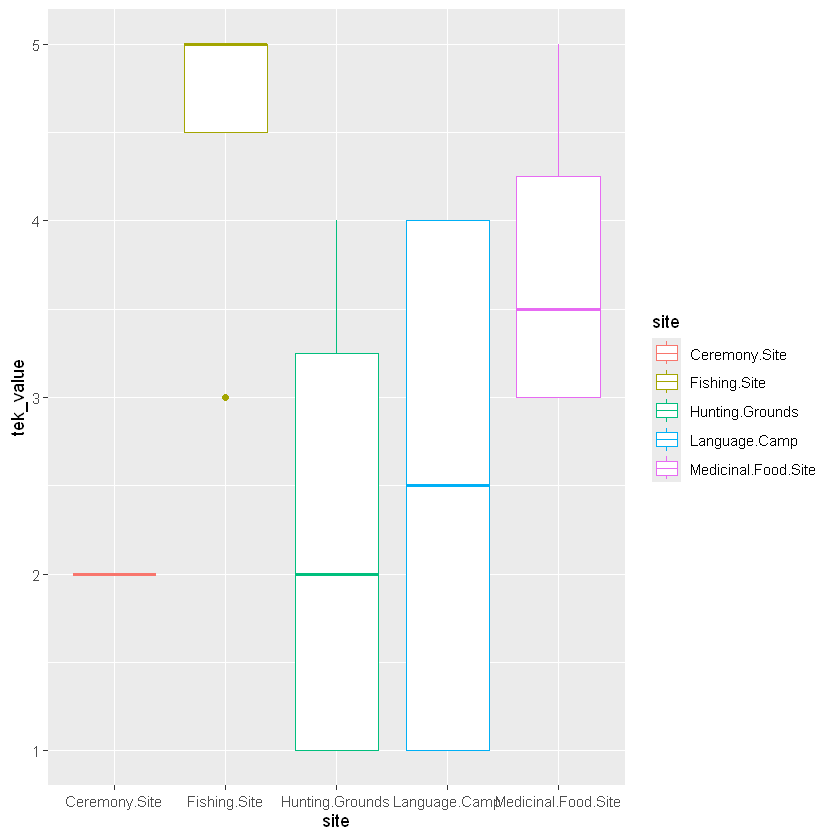

In [17]:

# we can visualize the data as-is before summarizing 
# because we pivoted longer, we can make the 'site' variable a color in our plots 
ggplot(tek_values_piv, aes(y=tek_value, x=site, col=site)) + geom_boxplot()


## Summarizing survey results

Based on photo, each monitoring site is located relatively close to one of the cultural sites, we will pair each one below 

The following formatting is assigning a value to the rows wherever the statement inside the bracket is true.
For example: 
`dataframe$new_column[dataframe$existing_column=="existing label"] <- "new label"`

Once the new column `sample_location` has been created, we summarize results by grouping by the `sample_location` and save the summary data frame. 

In [19]:
 
tek_values_piv$sample_location = NA # create a new column 
# next assign values to sample_location based on site rows 

# monitoring site 1 pairs with ceremony site
tek_values_piv$sample_location[tek_values_piv$site=="Ceremony.Site"] <- "Monitoring Site 1"
# monitoring site 2 pairs with medicinal foods site
tek_values_piv$sample_location[tek_values_piv$site=="Medicinal.Food.Site"] <- "Monitoring Site 2"
# monitoring site 3 pairs with hunting grounds
tek_values_piv$sample_location[tek_values_piv$site=="Hunting.Grounds"] <- "Monitoring Site 3"
# monitoring site 4 pairs with fishing site
tek_values_piv$sample_location[tek_values_piv$site=="Fishing.Site"] <- "Monitoring Site 4"
# monitoring site 5 pairs with language camp
tek_values_piv$sample_location[tek_values_piv$site=="Language.Camp"] <- "Monitoring Site 5"

head(tek_values_piv)

site,tek_value,sample_location
<chr>,<int>,<chr>
Ceremony.Site,2,Monitoring Site 1
Medicinal.Food.Site,3,Monitoring Site 2
Hunting.Grounds,4,Monitoring Site 3
Fishing.Site,5,Monitoring Site 4
Language.Camp,1,Monitoring Site 5
Ceremony.Site,2,Monitoring Site 1


In [21]:
# gather summary statistics on the TEK value dataset by site
# in this use of summary, we only have one variable, so we are running the functions directly 
tek_summary <- tek_values_piv %>%
  group_by(site, sample_location) %>%
  summarize(mean_tek = mean(tek_value),
            sd = sd(tek_value),
            n = length(tek_value),
            se_tek = sd / sqrt(n))

head(tek_summary)

# write summary table as a csv
write.csv(tek_summary, "tek_summary.csv")


`summarise()` has grouped output by 'site'. You can override using the `.groups` argument.


site,sample_location,mean_tek,sd,n,se_tek
<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>
Ceremony.Site,Monitoring Site 1,2.00,0.0000000,4,0.0000000
Fishing.Site,Monitoring Site 4,4.50,1.0000000,4,0.5000000
Hunting.Grounds,Monitoring Site 3,2.25,1.5000000,4,0.7500000
Language.Camp,Monitoring Site 5,2.50,1.7320508,4,0.8660254
Medicinal.Food.Site,Monitoring Site 2,3.75,0.9574271,4,0.4787136


## Visualize survey data with water temperature 

We will first bring in the water quality dataset that we cleaned in Part 1. We then summarize it by sampling location, similar to what we did above with the survey results. 



In [22]:

# if you need to reload water data, do that here
water_num <- readr::read_csv("K-avi_tribe_water_quality_dataset_clean.csv")

# summarize the water temperature data by sampling location
temp_summary <- water_num %>%
  group_by(sample_location) %>%
  summarise(mean_temp = mean(water_temp_C),
            # calculate the standard deviation
            sd_temp = sd(water_temp_C),
            # calculate the number of observations
            n_temp = length(water_temp_C),
            # calculate the standard error
            se_temp = sd_temp / sqrt(n_temp))


New names:
• `` -> `...1`
Rows: 561 Columns: 11
── Column specification ────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): sample_location, longitude, latitude
dbl  (7): ...1, DO, water_temp_C, water_temp_F, specific_conductivity, disch...
date (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### Joining data frames 

Next we combine our two summary datasets: `temp` and `tek `. 
We use `inner_join()`, which looks for the column that is the same in each dataset and matches them together. 

If you want to learn more about a function, use a `?` before the function name in your console. An example is commented out below.


In [23]:

#?inner_join

tek_water_temp_data <- inner_join(temp_summary, tek_summary)


Joining with `by = join_by(sample_location)`


### Create a plot 

With the joined data frame `tek_water_temp_data` we use `ggplot()` to create a scatter plot with `geom_point()`, where each point represents the mean value, with error bars to represent the standard error, using `geom_errorbar()` and `geom_errorbarh()`.


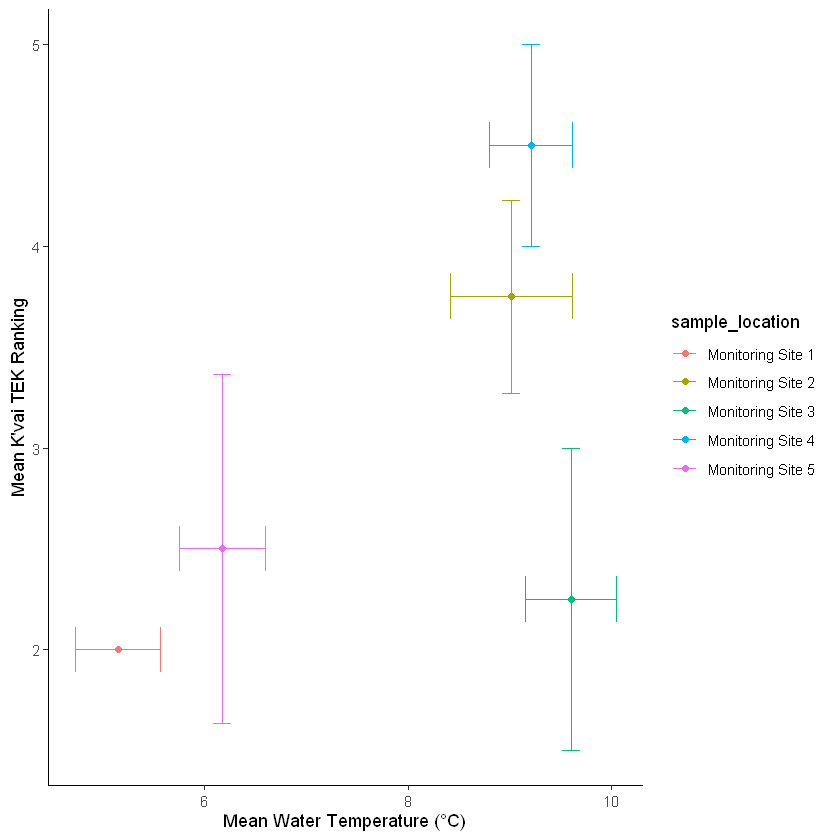

In [24]:
# plot mean temp v mean tek by paired site with standard error for each
tek_water_temp_data %>%
  ggplot(aes(x = mean_temp, y = mean_tek,
             xmin = mean_temp - se_temp, xmax = mean_temp + se_temp,
             ymin = mean_tek - se_tek, ymax = mean_tek + se_tek)) +
  geom_point(aes(color = sample_location)) +
  geom_errorbar(aes(color = sample_location)) +
  geom_errorbarh(aes(color = sample_location)) +
  xlab("Mean Water Temperature (°C)") +
  ylab("Mean K'vai TEK Ranking") +
  theme_classic()



## We can repeat this process with the DO data

- create a new dataframe that summarizes the mean DO from the `water_num` dataframe that we read in, using `group_by()` and `summarise()`
- join this data frame with the TEK survey results, using `inner_join()`
- create scatter plot with error bars, using `ggplot()`, `geom_point()`, and `geom_errorbar()`, `geom_errorbarh()`  


Joining with `by = join_by(sample_location)`


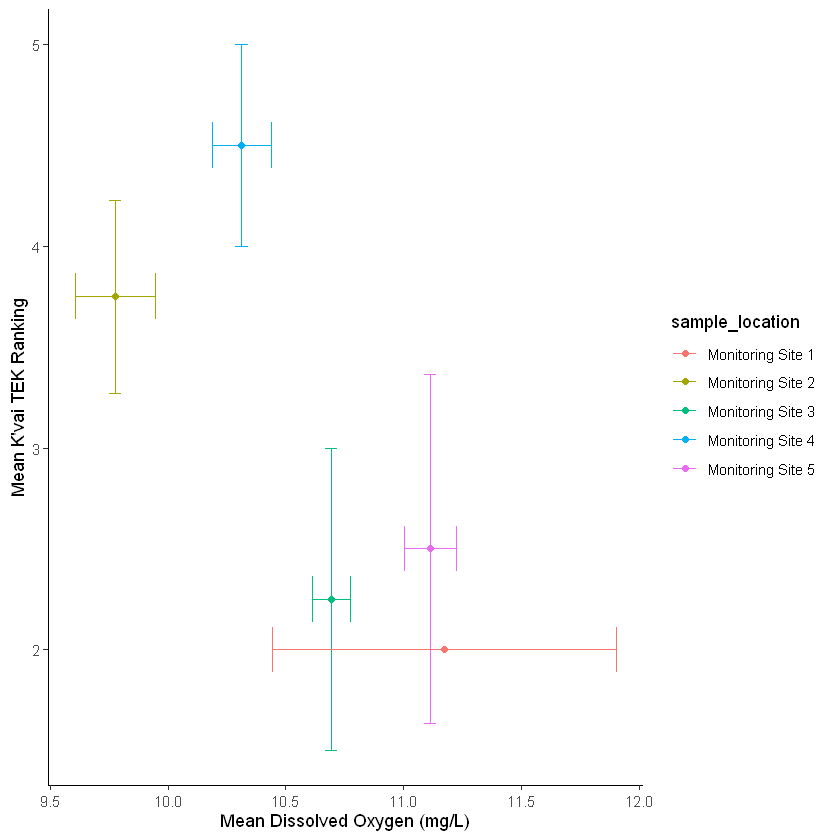

In [19]:

# summarise DO by location only 
do_summary <- water_num %>%
  group_by(sample_location) %>%
  summarise(mean_DO = mean(DO),
            # calculate the standard deviation
            sd_DO = sd(DO),
            # calculate the number of observations
            n_DO = length(DO),
            # calculate the standard error
            se_DO = sd_DO / sqrt(n_DO))

# join 
tek_water_data <- inner_join(do_summary, tek_summary)

# plot 
tek_water_data %>%
  ggplot(aes(x = mean_DO, y = mean_tek,
             xmin = mean_DO - se_DO, xmax = mean_DO + se_DO,
             ymin = mean_tek - se_tek, ymax = mean_tek + se_tek)) +
  geom_point(aes(color = sample_location)) +
  geom_errorbar(aes(color = sample_location)) +
  geom_errorbarh(aes(color = sample_location)) +
  xlab("Mean Dissolved Oxygen (mg/L)") +
  ylab("Mean K'vai TEK Ranking") +
  theme_classic()

Summary paragraph about plot 

## Part 2 Recap 

topics covered: 
- summarized TEK location rankings and plotted with water sample 
- more ggplot and tidyverse 
- new functions introduced: pivot_longer and inner_join